In [16]:
import numpy as np
from pathlib import Path
import pandas as pd
import akshare as ak
import matplotlib.pyplot as plt
import sys

project_root = Path.cwd().parent
src_path = project_root / "src"
sys.path.append(str(src_path))

%load_ext autoreload
%autoreload 2

from backtest import (ma_cross_backtest,
                      backtest_plot_drawdown,
                      backtest_plot_nav,
                      backtest_plot_sbpoints,
                      calculate_performance,
                      calculate_buy_and_sell,
                      format_batch_summary,
                      run_batch_ma_backtest,
                      summarize_backtest_period,
                      run_ma_parameter_grid_search)


RAW_DIR = project_root / "data" / "raw"
PROCESSED_DIR = project_root / "data" / "processed"
REPORT_DIR = project_root / "reports"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


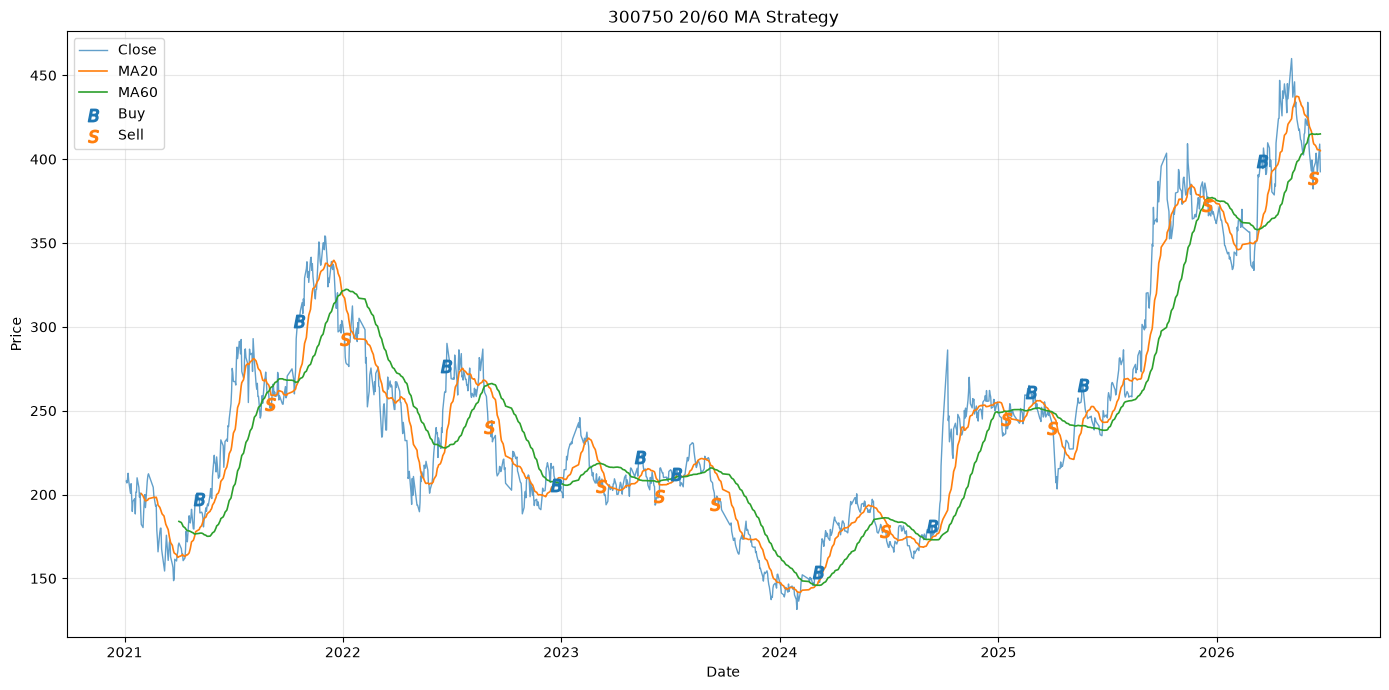

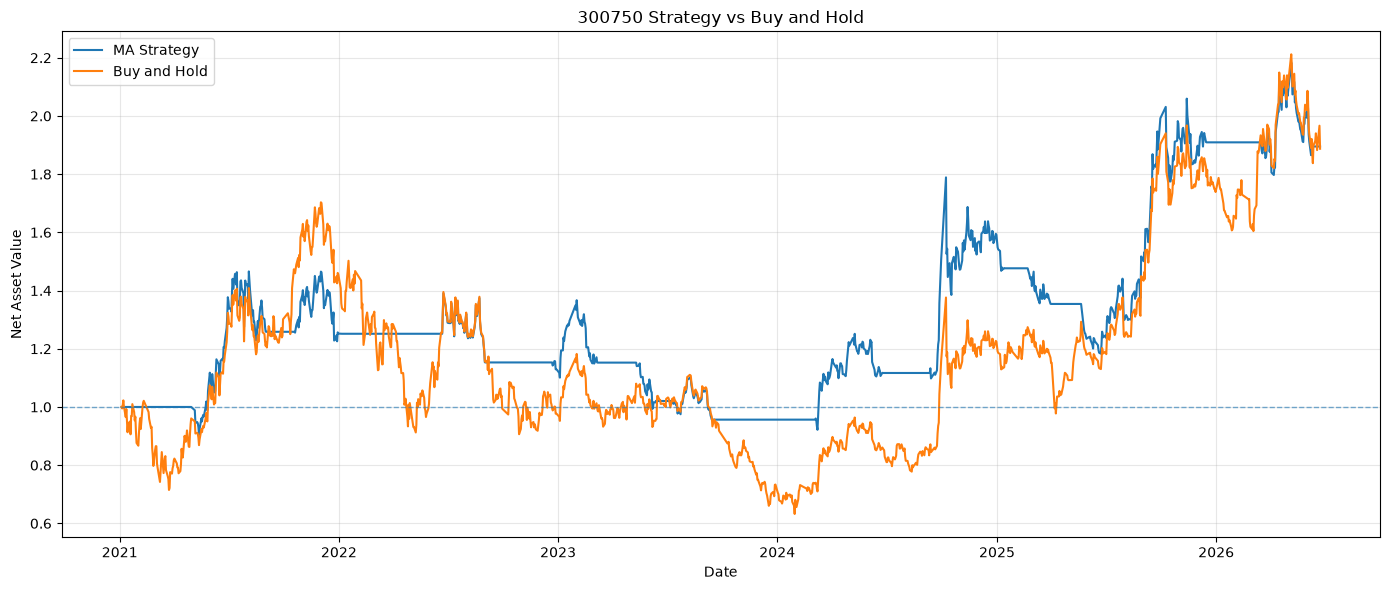

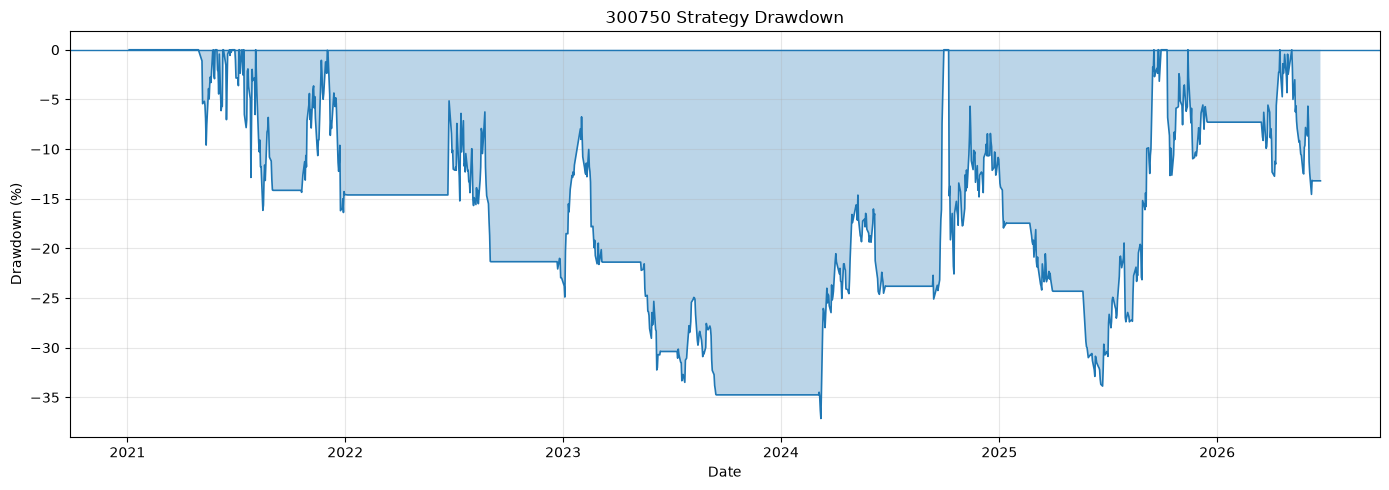

In [5]:
symbol = "300750"
df = pd.read_csv(f"{RAW_DIR}\{symbol}_qfq_daily.csv")
result = ma_cross_backtest(df)
backtest_plot_sbpoints(result)
backtest_plot_nav(result)
backtest_plot_drawdown(result)

In [6]:
# 要把两种策略在同一起跑线上进行比较，因此要排除均线没有形成时的数据，此时只有单次buy的数据但没有均线策略数据
evaluation_mask = (
    result["slow_ma"]
    .shift(1)
    .notna()
)

evaluation_data = (
    result.loc[evaluation_mask]
    .copy()
    .reset_index(drop=True)
)

print(
    "绩效评价开始日期：",
    evaluation_data["date"].iloc[0],
)

print(
    "绩效评价结束日期：",
    evaluation_data["date"].iloc[-1],
)

print(
    "评价交易日数量：",
    len(evaluation_data),
)

evaluation_data["strategy_nav_eval"] = (
    1 + evaluation_data["strategy_return"]
).cumprod()

evaluation_data["benchmark_nav_eval"] = (
    1 + evaluation_data["asset_return"]
).cumprod()


绩效评价开始日期： 2021-04-06 00:00:00
绩效评价结束日期： 2026-06-23 00:00:00
评价交易日数量： 1263


In [7]:
strategy_metrics = calculate_performance(
    returns=evaluation_data["strategy_return"],
    annual_risk_free_rate=0.0,
    trading_days=252,
)

benchmark_metrics = calculate_performance(
    returns=evaluation_data["asset_return"],
    annual_risk_free_rate=0.0,
    trading_days=252,
)

performance_comparison = pd.DataFrame(
    {
        "MA Strategy": strategy_metrics,
        "Buy and Hold": benchmark_metrics,
    }
).T

# 把浮点数转成两位小数的百分数
performance_display = (
    performance_comparison.copy()
)

percentage_cols = [
    "cumulative_return",
    "annual_return",
    "annual_volatility",
    "max_drawdown",
]

for col in percentage_cols:
    performance_display[col] = (
        performance_display[col]
        .map(lambda value: f"{value:.2%}")
    )

ratio_cols = [
    "sharpe_ratio",
    "calmar_ratio",
]

for col in ratio_cols:
    performance_display[col] = (
        performance_display[col]
        .map(
            lambda value: (
                "NaN"
                if pd.isna(value)
                else f"{value:.3f}"
            )
        )
    )

# 转成中文，更易阅读
column_name_map = {
    "cumulative_return": "累计收益率",
    "annual_return": "年化收益率",
    "annual_volatility": "年化波动率",
    "sharpe_ratio": "夏普比率",
    "max_drawdown": "最大回撤",
    "calmar_ratio": "卡玛比率",
}

performance_display_cn = (
    performance_display
    .rename(columns=column_name_map)
    .rename(
        index={
            "MA Strategy": "20/60均线策略",
            "Buy and Hold": "买入持有",
        }
    )
)

display(performance_display_cn)

,累计收益率,年化收益率,年化波动率,夏普比率,最大回撤,卡玛比率
20/60均线策略,89.51%,13.60%,31.66%,0.559,-37.13%,0.366
买入持有,129.44%,18.02%,42.26%,0.601,-62.88%,0.287


In [8]:
# 计算买卖次数
buy_and_sell = pd.Series(calculate_buy_and_sell(evaluation_data))
display(buy_and_sell)

评价交易日数量     1263.000000
持仓比例           0.540776
买入次数          11.000000
卖出次数          11.000000
总交易次数         22.000000
交易成本简单加总       0.011000
dtype: float64

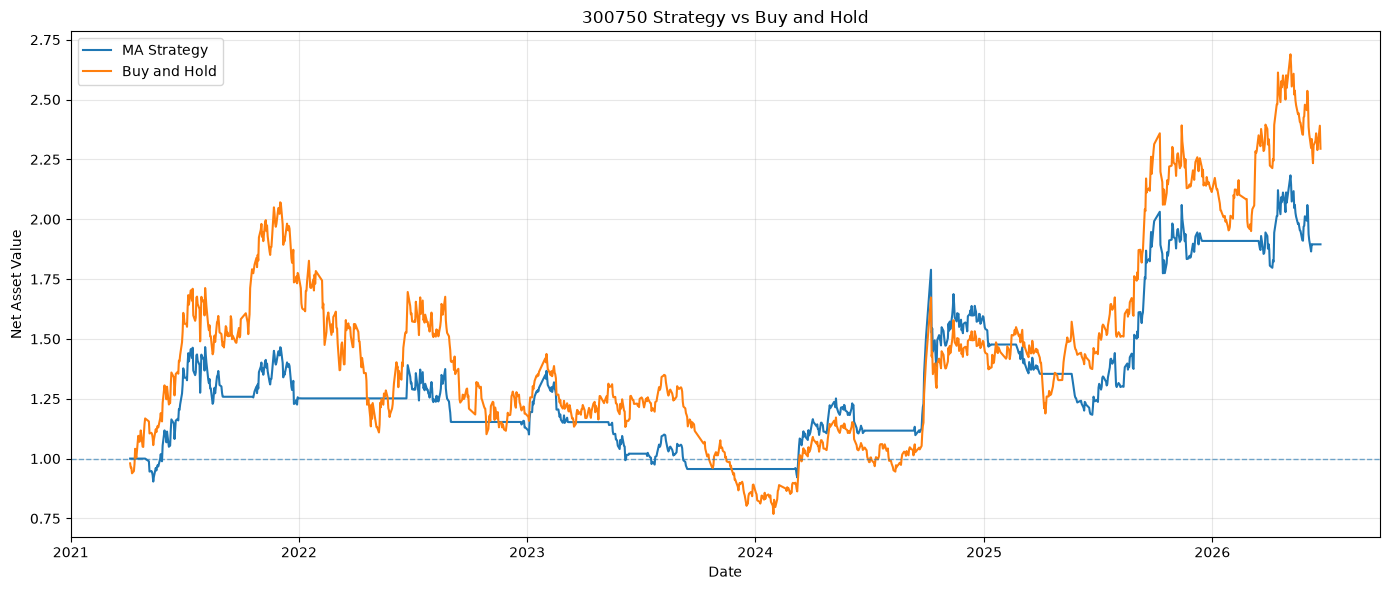

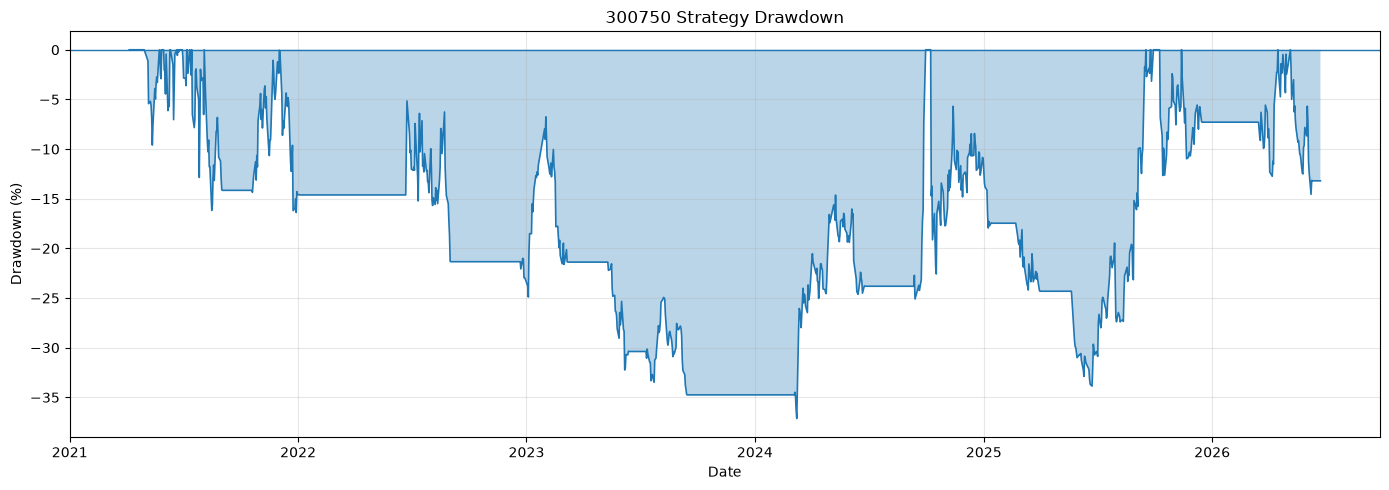

In [9]:
# 绘制新的收益图和回撤图
backtest_plot_nav(evaluation_data, strategy_nav="strategy_nav_eval", benchmark_nav="benchmark_nav_eval")
backtest_plot_drawdown(evaluation_data)

In [10]:
stock_list = [
    "000001",
    "000002",
    "600519",
    "600036",
    "300750",
]

batch_summary, batch_results = run_batch_ma_backtest(
    stock_list=stock_list,
    fast_window=20,
    slow_window=60,
    commission_rate=0.0003,
    slippage_rate=0.0002,
    annual_risk_free_rate=0.0,
    trading_days=252,
    save_result=True,
)

display(batch_summary)

正在回测：000001
正在回测：000002
正在回测：600519
正在回测：600036
正在回测：300750
原始批量回测结果已保存到：E:\quant-learning\reports\ma_20_60_batch_summary_raw.csv
展示版批量回测结果已保存到：E:\quant-learning\reports\ma_20_60_batch_summary_display.csv


,symbol,start_date,end_date,trade_days,strategy_cumulative_return,strategy_annual_return,strategy_annual_volatility,strategy_sharpe,strategy_max_drawdown,strategy_calmar,...,benchmark_max_drawdown,benchmark_calmar,excess_annual_return,sharpe_diff,drawdown_improvement,exposure,buy_count,sell_count,total_trade_count,total_transaction_cost
0,300750,2021-04-06,2026-06-23,1263,0.895114,0.136044,0.316563,0.558778,-0.371283,0.366416,...,-0.628783,0.286622,-0.044179,-0.042594,0.257499,0.540776,11,11,22,0.011
1,000001,2021-04-06,2026-06-23,1263,-0.252006,-0.056288,0.157914,-0.288151,-0.322822,-0.174362,...,-0.623138,-0.144399,0.033693,-0.058234,0.300316,0.367379,14,14,28,0.014
2,600519,2021-04-06,2026-06-23,1263,-0.273930,-0.061873,0.146281,-0.363478,-0.299759,-0.206408,...,-0.398508,-0.210169,0.021881,-0.161550,0.098749,0.435471,13,13,26,0.013
3,600036,2021-04-06,2026-06-23,1263,-0.334618,-0.078069,0.161046,-0.424220,-0.428132,-0.182348,...,-0.509310,-0.023826,-0.065934,-0.509318,0.081177,0.475851,16,16,32,0.016
4,000002,2021-04-06,2026-06-23,1263,-0.725223,-0.227208,0.174076,-1.392242,-0.724823,-0.313466,...,-0.878330,-0.390696,0.115952,-0.457085,0.153507,0.258907,13,13,26,0.013


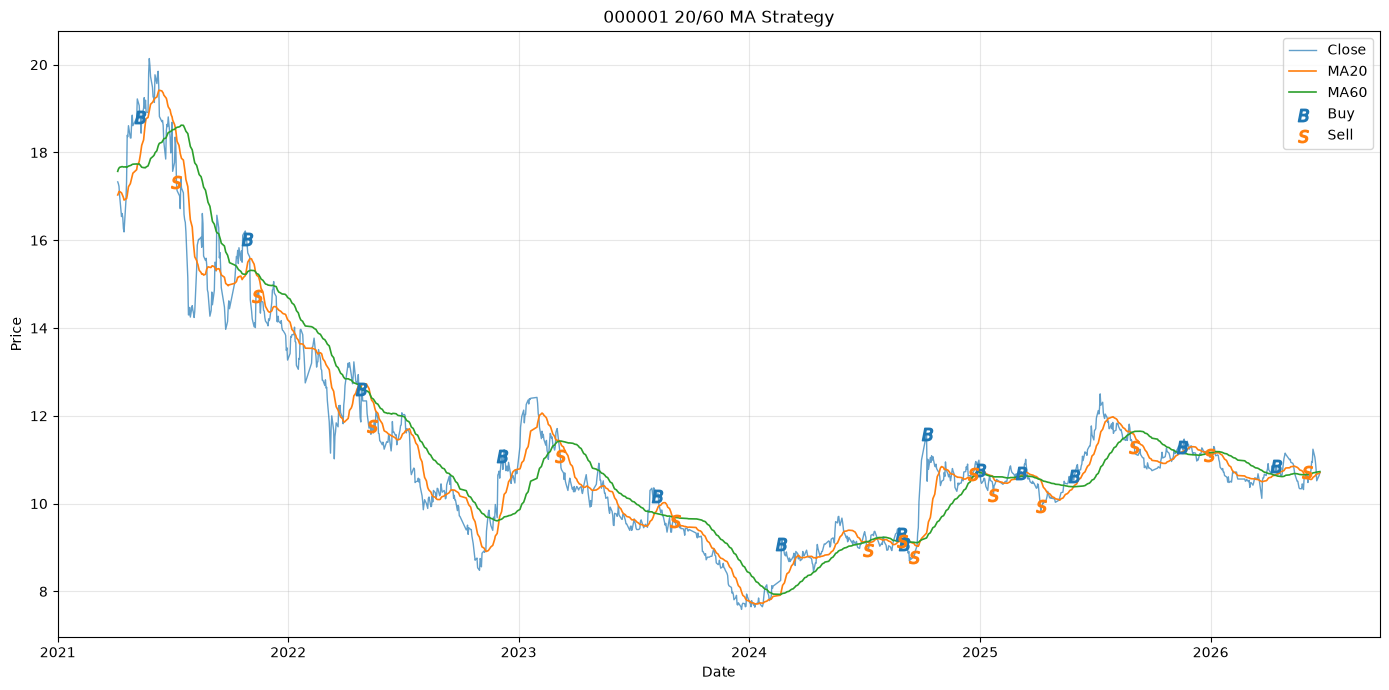

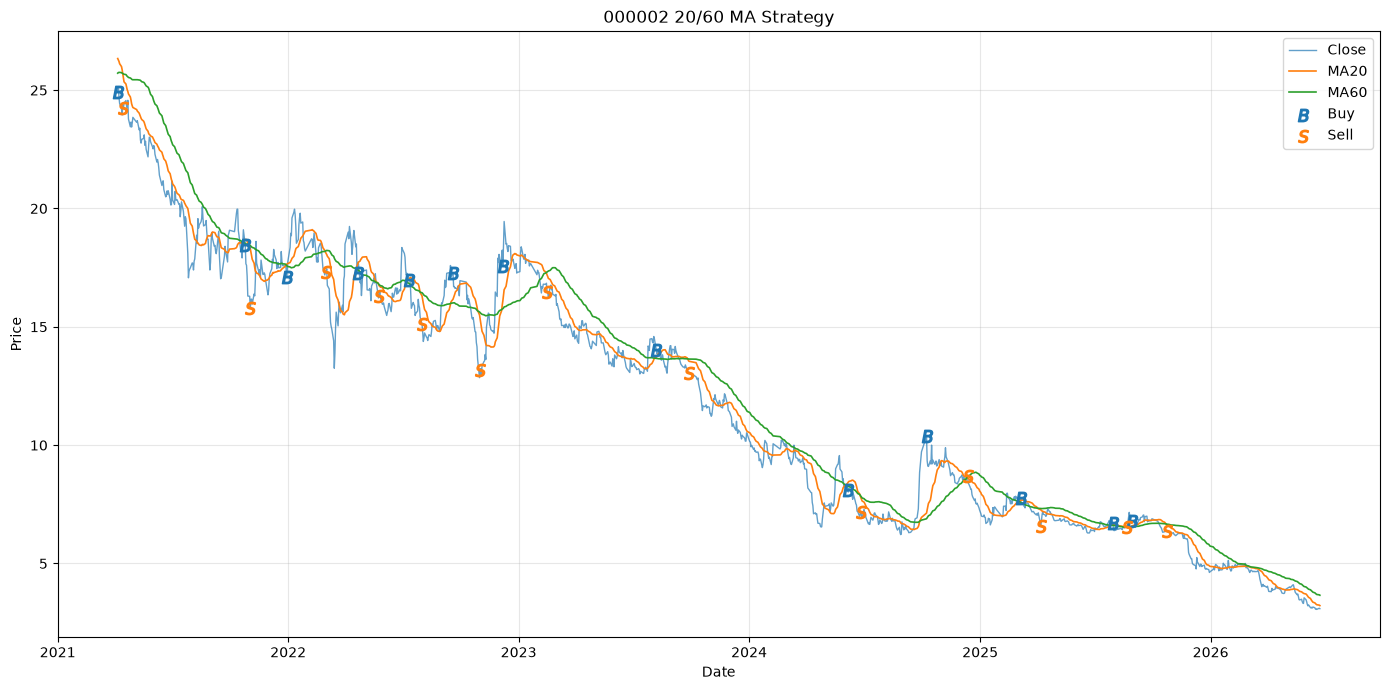

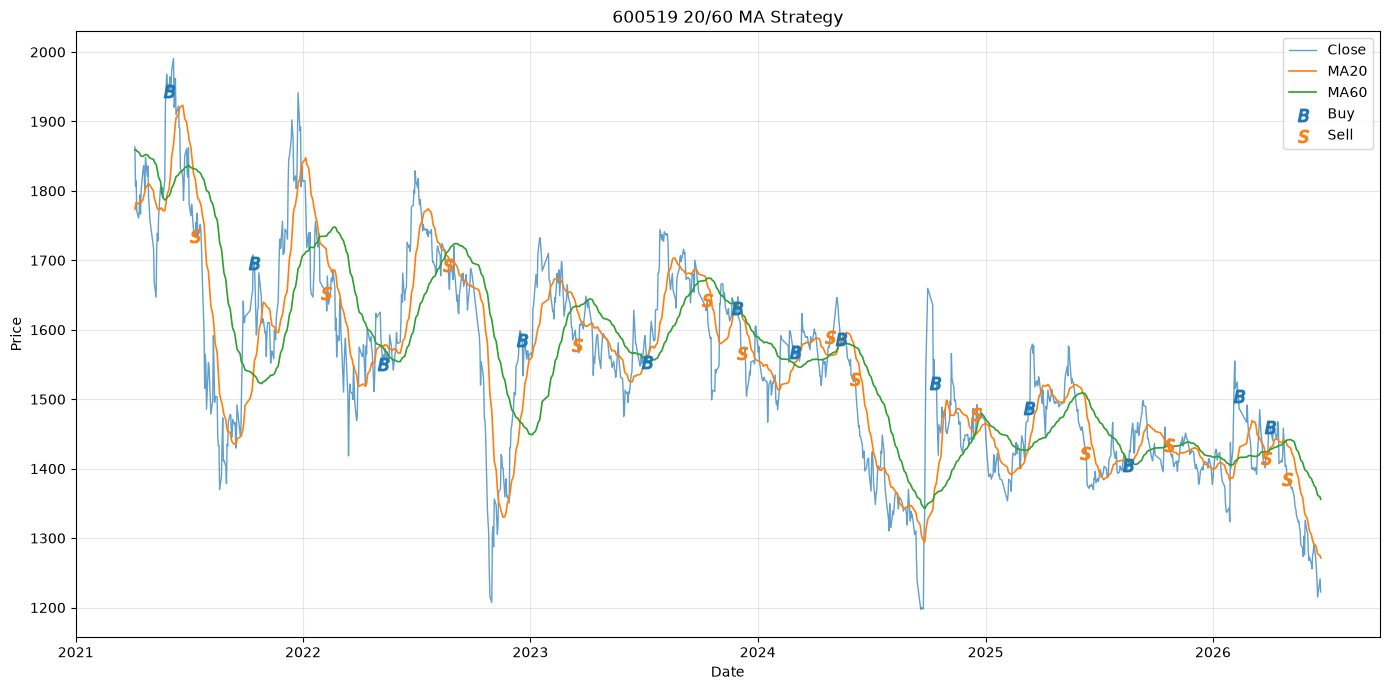

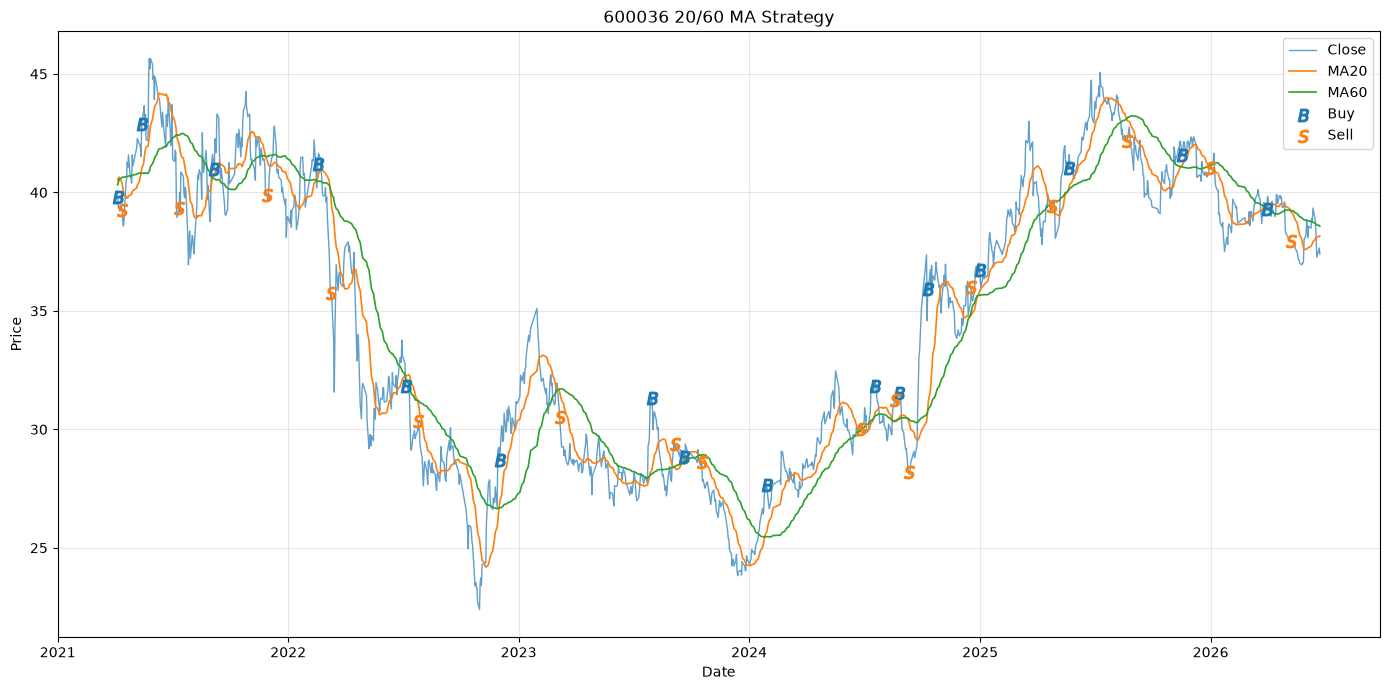

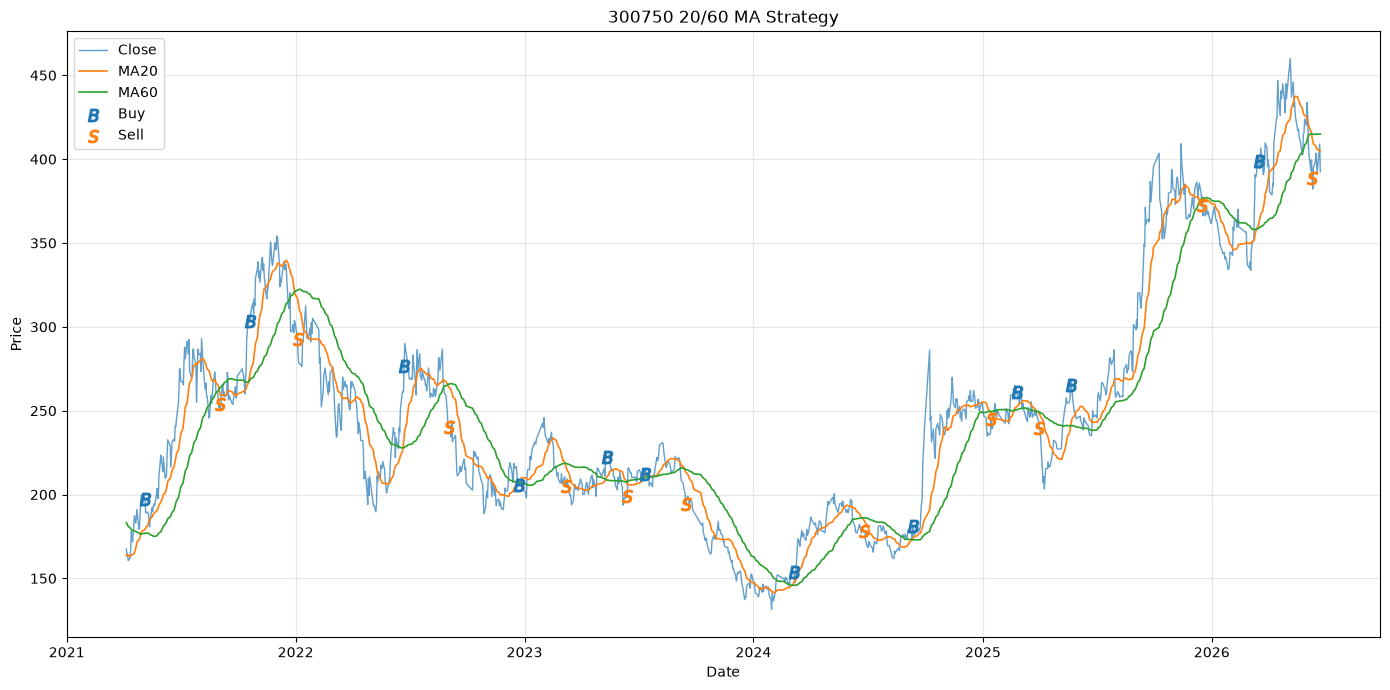

In [ ]:

for symbol, result in batch_results.items():
    evaluation_mask = (
        result["slow_ma"]
        .shift(1)
        .notna()
    )

    evaluation_data = (
        result.loc[evaluation_mask]
        .copy()
        .reset_index(drop=True)
    )

    strategy_nav = (
        1 + evaluation_data["strategy_return"]
    ).cumprod()
    
    backtest_plot_sbpoints(evaluation_data)



将数据分为训练集（样本内）和测试集（样本外），用于检验参数是否具有可泛化性

In [15]:
in_sample_end = "2024-12-31"
out_sample_start = "2025-01-01"

period_rows = []

for symbol, backtest_result in batch_results.items():
    print(f"正在汇总：{symbol}")

    in_sample_summary = summarize_backtest_period(
        result=backtest_result,
        period_name="in_sample",
        start_date=None,
        end_date=in_sample_end,
        annual_risk_free_rate=0.0,
        trading_days=252,
    )

    out_sample_summary = summarize_backtest_period(
        result=backtest_result,
        period_name="out_sample",
        start_date=out_sample_start,
        end_date=None,
        annual_risk_free_rate=0.0,
        trading_days=252,
    )

    period_rows.append(in_sample_summary)
    period_rows.append(out_sample_summary)

period_summary = pd.DataFrame(period_rows)

period_core_cols = [
    "symbol",
    "period",

    "strategy_annual_return",
    "benchmark_annual_return",
    "excess_annual_return",

    "strategy_sharpe",
    "benchmark_sharpe",
    "sharpe_diff",

    "strategy_max_drawdown",
    "benchmark_max_drawdown",
    "drawdown_improvement",

    "exposure",
    "total_trade_count",
]

period_core = period_summary[period_core_cols].copy()

wide_summary = period_summary.pivot(
    index="symbol",
    columns="period",
    values=[
        "strategy_annual_return",
        "benchmark_annual_return",
        "excess_annual_return",
        "strategy_sharpe",
        "benchmark_sharpe",
        "sharpe_diff",
        "strategy_max_drawdown",
        "benchmark_max_drawdown",
        "drawdown_improvement",
        "exposure",
        "total_trade_count",
    ],
)

wide_summary.columns = [
    f"{metric}_{period}"
    for metric, period in wide_summary.columns
]

wide_summary = wide_summary.reset_index()

display(wide_summary)

正在汇总：000001
正在汇总：000002
正在汇总：600519
正在汇总：600036
正在汇总：300750


,symbol,strategy_annual_return_in_sample,strategy_annual_return_out_sample,benchmark_annual_return_in_sample,benchmark_annual_return_out_sample,excess_annual_return_in_sample,excess_annual_return_out_sample,strategy_sharpe_in_sample,strategy_sharpe_out_sample,benchmark_sharpe_in_sample,...,strategy_max_drawdown_in_sample,strategy_max_drawdown_out_sample,benchmark_max_drawdown_in_sample,benchmark_max_drawdown_out_sample,drawdown_improvement_in_sample,drawdown_improvement_out_sample,exposure_in_sample,exposure_out_sample,total_trade_count_in_sample,total_trade_count_out_sample
0,000001,-0.058247,-0.051239,-0.121657,-0.003310,0.063410,-0.047929,-0.269745,-0.363849,-0.299935,...,-0.247755,-0.143340,-0.623138,-0.190400,0.375383,0.047060,0.331133,0.460452,19.0,9.0
1,000002,-0.270744,-0.103135,-0.293330,-0.455605,0.022586,0.352470,-1.516076,-1.039620,-0.698790,...,-0.687167,-0.175310,-0.752684,-0.616060,0.065517,0.440750,0.280528,0.203390,20.0,6.0
2,300750,0.137494,0.132330,0.116561,0.360820,0.020933,-0.228490,0.558602,0.559235,0.467942,...,-0.371283,-0.235902,-0.628783,-0.232850,0.257499,-0.003052,0.496150,0.655367,15.0,7.0
3,600036,-0.114851,0.023533,-0.021809,0.013148,-0.093042,0.010385,-0.624611,0.244505,0.069476,...,-0.428132,-0.120930,-0.509310,-0.180386,0.081177,0.059456,0.446645,0.550847,25.0,7.0
4,600519,-0.051399,-0.088240,-0.068047,-0.122885,0.016648,0.034645,-0.271199,-0.641665,-0.108053,...,-0.219356,-0.169107,-0.398508,-0.230759,0.179152,0.061653,0.446645,0.406780,18.0,8.0


网格搜索，优化策略的超参数


In [19]:
stock_list = [
    "000001",
    "000002",
    "600519",
    "600036",
    "300750",
]

param_grid = [
    (10, 30),
    (20, 60),
    (20, 120),
    (50, 200),
]

grid_summary, grid_results = run_ma_parameter_grid_search(
    stock_list=stock_list,
    param_grid=param_grid,
    in_sample_end="2024-12-31",
    commission_rate=0.0003,
    slippage_rate=0.0002,
    annual_risk_free_rate=0.0,
    trading_days=252,
)

grid_core = grid_summary[
    [
        "symbol",
        "ma_param",

        "strategy_annual_return",
        "benchmark_annual_return",
        "excess_annual_return",

        "strategy_sharpe",
        "benchmark_sharpe",
        "sharpe_diff",

        "strategy_max_drawdown",
        "benchmark_max_drawdown",
        "drawdown_improvement",

        "exposure",
        "total_trade_count",
    ]
].copy()

display(grid_core)


正在测试参数：10/30

正在测试参数：20/60

正在测试参数：20/120

正在测试参数：50/200


,symbol,ma_param,strategy_annual_return,benchmark_annual_return,excess_annual_return,strategy_sharpe,benchmark_sharpe,sharpe_diff,strategy_max_drawdown,benchmark_max_drawdown,drawdown_improvement,exposure,total_trade_count
0,000001,10/30,-0.155830,-0.142250,-0.013580,-0.781201,-0.366068,-0.415134,-0.533050,-0.623138,0.090088,0.385517,39
1,000002,10/30,-0.083699,-0.284463,0.200764,-0.235139,-0.665132,0.429993,-0.433682,-0.780754,0.347072,0.314164,34
2,300750,10/30,0.256578,0.067763,0.188816,0.839133,0.368680,0.470453,-0.371744,-0.628783,0.257039,0.509052,39
3,600036,10/30,-0.055494,-0.041903,-0.013591,-0.177233,0.004247,-0.181480,-0.340311,-0.509310,0.168999,0.473908,43
4,600519,10/30,-0.086894,-0.097761,0.010868,-0.432407,-0.208399,-0.224008,-0.346028,-0.407896,0.061867,0.413206,35
5,000001,20/60,-0.058247,-0.121657,0.063410,-0.269745,-0.299935,0.030190,-0.247755,-0.623138,0.375383,0.331133,19
6,000002,20/60,-0.270744,-0.293330,0.022586,-1.516076,-0.698790,-0.817286,-0.687167,-0.752684,0.065517,0.280528,20
7,300750,20/60,0.137494,0.116561,0.020933,0.558602,0.467942,0.090659,-0.371283,-0.628783,0.257499,0.496150,15
8,600036,20/60,-0.114851,-0.021809,-0.093042,-0.624611,0.069476,-0.694087,-0.428132,-0.509310,0.081177,0.446645,25
9,600519,20/60,-0.051399,-0.068047,0.016648,-0.271199,-0.108053,-0.163146,-0.219356,-0.398508,0.179152,0.446645,18


评估网格搜索后的超参数模型<br>
统计平均值

In [20]:
param_summary = (
    grid_summary
    .groupby("ma_param")
    .agg(
        fast_window=("fast_window", "first"),
        slow_window=("slow_window", "first"),

        stock_count=("symbol", "nunique"),

        avg_strategy_annual_return=(
            "strategy_annual_return",
            "mean",
        ),
        avg_benchmark_annual_return=(
            "benchmark_annual_return",
            "mean",
        ),
        avg_excess_annual_return=(
            "excess_annual_return",
            "mean",
        ),

        avg_strategy_sharpe=(
            "strategy_sharpe",
            "mean",
        ),
        avg_benchmark_sharpe=(
            "benchmark_sharpe",
            "mean",
        ),
        avg_sharpe_diff=(
            "sharpe_diff",
            "mean",
        ),

        avg_strategy_max_drawdown=(
            "strategy_max_drawdown",
            "mean",
        ),
        avg_benchmark_max_drawdown=(
            "benchmark_max_drawdown",
            "mean",
        ),
        avg_drawdown_improvement=(
            "drawdown_improvement",
            "mean",
        ),

        avg_exposure=(
            "exposure",
            "mean",
        ),
        avg_trade_count=(
            "total_trade_count",
            "mean",
        ),
    )
    .reset_index()
)

display(param_summary)

,ma_param,fast_window,slow_window,stock_count,avg_strategy_annual_return,avg_benchmark_annual_return,avg_excess_annual_return,avg_strategy_sharpe,avg_benchmark_sharpe,avg_sharpe_diff,avg_strategy_max_drawdown,avg_benchmark_max_drawdown,avg_drawdown_improvement,avg_exposure,avg_trade_count
0,10/30,10,30,5,-0.025068,-0.099723,0.074655,-0.157369,-0.173334,0.015965,-0.404963,-0.589976,0.185013,0.419169,38.0
1,20/120,20,120,5,-0.101221,-0.100798,-0.000424,-0.556727,-0.157533,-0.399194,-0.407280,-0.558426,0.151145,0.378092,13.4
2,20/60,20,60,5,-0.071549,-0.077656,0.006107,-0.424606,-0.113872,-0.310734,-0.390739,-0.582485,0.191746,0.400220,19.4
3,50/200,50,200,5,-0.087763,-0.095715,0.007952,-0.680858,-0.134427,-0.546431,-0.387179,-0.534640,0.147461,0.315475,5.4


统计策略胜率

In [21]:
param_win_summary = (
    grid_summary
    .assign(
        return_win=(
            grid_summary["excess_annual_return"] > 0
        ),
        sharpe_win=(
            grid_summary["sharpe_diff"] > 0
        ),
        drawdown_win=(
            grid_summary["drawdown_improvement"] > 0
        ),
    )
    .groupby("ma_param")
    .agg(
        return_win_count=("return_win", "sum"),
        sharpe_win_count=("sharpe_win", "sum"),
        drawdown_win_count=("drawdown_win", "sum"),
    )
    .reset_index()
)

param_summary = param_summary.merge(
    param_win_summary,
    on="ma_param",
    how="left",
)

param_summary["return_win_rate"] = (
    param_summary["return_win_count"]
    / param_summary["stock_count"]
)

param_summary["sharpe_win_rate"] = (
    param_summary["sharpe_win_count"]
    / param_summary["stock_count"]
)

param_summary["drawdown_win_rate"] = (
    param_summary["drawdown_win_count"]
    / param_summary["stock_count"]
)

display(param_summary)

,ma_param,fast_window,slow_window,stock_count,avg_strategy_annual_return,avg_benchmark_annual_return,avg_excess_annual_return,avg_strategy_sharpe,avg_benchmark_sharpe,avg_sharpe_diff,...,avg_benchmark_max_drawdown,avg_drawdown_improvement,avg_exposure,avg_trade_count,return_win_count,sharpe_win_count,drawdown_win_count,return_win_rate,sharpe_win_rate,drawdown_win_rate
0,10/30,10,30,5,-0.025068,-0.099723,0.074655,-0.157369,-0.173334,0.015965,...,-0.589976,0.185013,0.419169,38.0,3,2,5,0.6,0.4,1.0
1,20/120,20,120,5,-0.101221,-0.100798,-0.000424,-0.556727,-0.157533,-0.399194,...,-0.558426,0.151145,0.378092,13.4,2,1,4,0.4,0.2,0.8
2,20/60,20,60,5,-0.071549,-0.077656,0.006107,-0.424606,-0.113872,-0.310734,...,-0.582485,0.191746,0.400220,19.4,4,2,5,0.8,0.4,1.0
3,50/200,50,200,5,-0.087763,-0.095715,0.007952,-0.680858,-0.134427,-0.546431,...,-0.534640,0.147461,0.315475,5.4,3,2,4,0.6,0.4,0.8


评估最优参数

In [23]:
param_selection = (
    param_summary
    .sort_values(
        by=[
            "sharpe_win_rate",
            "drawdown_win_rate",
            "avg_trade_count",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(param_selection)

best_param_row = param_selection.iloc[0]

best_fast_window = int(
    best_param_row["fast_window"]
)

best_slow_window = int(
    best_param_row["slow_window"]
)

print(
    "样本内选择的最佳参数：",
    f"{best_fast_window}/{best_slow_window}",
)

,ma_param,fast_window,slow_window,stock_count,avg_strategy_annual_return,avg_benchmark_annual_return,avg_excess_annual_return,avg_strategy_sharpe,avg_benchmark_sharpe,avg_sharpe_diff,...,avg_benchmark_max_drawdown,avg_drawdown_improvement,avg_exposure,avg_trade_count,return_win_count,sharpe_win_count,drawdown_win_count,return_win_rate,sharpe_win_rate,drawdown_win_rate
0,20/60,20,60,5,-0.071549,-0.077656,0.006107,-0.424606,-0.113872,-0.310734,...,-0.582485,0.191746,0.400220,19.4,4,2,5,0.8,0.4,1.0
1,10/30,10,30,5,-0.025068,-0.099723,0.074655,-0.157369,-0.173334,0.015965,...,-0.589976,0.185013,0.419169,38.0,3,2,5,0.6,0.4,1.0
2,50/200,50,200,5,-0.087763,-0.095715,0.007952,-0.680858,-0.134427,-0.546431,...,-0.534640,0.147461,0.315475,5.4,3,2,4,0.6,0.4,0.8
3,20/120,20,120,5,-0.101221,-0.100798,-0.000424,-0.556727,-0.157533,-0.399194,...,-0.558426,0.151145,0.378092,13.4,2,1,4,0.4,0.2,0.8


样本内选择的最佳参数： 20/60


In [24]:
param_display = param_summary.copy()

percent_cols = [
    "avg_strategy_annual_return",
    "avg_benchmark_annual_return",
    "avg_excess_annual_return",
    "avg_strategy_max_drawdown",
    "avg_benchmark_max_drawdown",
    "avg_drawdown_improvement",
    "avg_exposure",
    "return_win_rate",
    "sharpe_win_rate",
    "drawdown_win_rate",
]

for col in percent_cols:
    param_display[col] = param_display[col].map(
        lambda x: f"{x:.2%}"
    )

ratio_cols = [
    "avg_strategy_sharpe",
    "avg_benchmark_sharpe",
    "avg_sharpe_diff",
]

for col in ratio_cols:
    param_display[col] = param_display[col].map(
        lambda x: "NaN" if pd.isna(x) else f"{x:.3f}"
    )

param_display["avg_trade_count"] = (
    param_display["avg_trade_count"]
    .map(lambda x: f"{x:.1f}")
)

param_display = param_display.rename(
    columns={
        "ma_param": "均线参数",
        "stock_count": "股票数量",

        "avg_strategy_annual_return": "平均策略年化收益",
        "avg_benchmark_annual_return": "平均买入持有年化收益",
        "avg_excess_annual_return": "平均超额年化收益",

        "avg_strategy_sharpe": "平均策略夏普",
        "avg_benchmark_sharpe": "平均买入持有夏普",
        "avg_sharpe_diff": "平均夏普差值",

        "avg_strategy_max_drawdown": "平均策略最大回撤",
        "avg_benchmark_max_drawdown": "平均买入持有最大回撤",
        "avg_drawdown_improvement": "平均回撤改善",

        "avg_exposure": "平均持仓比例",
        "avg_trade_count": "平均交易次数",

        "return_win_count": "收益跑赢数量",
        "sharpe_win_count": "夏普跑赢数量",
        "drawdown_win_count": "回撤改善数量",

        "return_win_rate": "收益跑赢比例",
        "sharpe_win_rate": "夏普跑赢比例",
        "drawdown_win_rate": "回撤改善比例",
    }
)

display(param_display)

,均线参数,fast_window,slow_window,股票数量,平均策略年化收益,平均买入持有年化收益,平均超额年化收益,平均策略夏普,平均买入持有夏普,平均夏普差值,...,平均买入持有最大回撤,平均回撤改善,平均持仓比例,平均交易次数,收益跑赢数量,夏普跑赢数量,回撤改善数量,收益跑赢比例,夏普跑赢比例,回撤改善比例
0,10/30,10,30,5,-2.51%,-9.97%,7.47%,-0.157,-0.173,0.016,...,-59.00%,18.50%,41.92%,38.0,3,2,5,60.00%,40.00%,100.00%
1,20/120,20,120,5,-10.12%,-10.08%,-0.04%,-0.557,-0.158,-0.399,...,-55.84%,15.11%,37.81%,13.4,2,1,4,40.00%,20.00%,80.00%
2,20/60,20,60,5,-7.15%,-7.77%,0.61%,-0.425,-0.114,-0.311,...,-58.25%,19.17%,40.02%,19.4,4,2,5,80.00%,40.00%,100.00%
3,50/200,50,200,5,-8.78%,-9.57%,0.80%,-0.681,-0.134,-0.546,...,-53.46%,14.75%,31.55%,5.4,3,2,4,60.00%,40.00%,80.00%


In [25]:
reports_dir = project_root / "reports"
reports_dir.mkdir(exist_ok=True)

grid_summary.to_csv(
    reports_dir / "ma_parameter_grid_in_sample_detail.csv",
    index=False,
    encoding="utf-8-sig",
)

param_summary.to_csv(
    reports_dir / "ma_parameter_grid_in_sample_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

param_display.to_csv(
    reports_dir / "ma_parameter_grid_in_sample_summary_display.csv",
    index=False,
    encoding="utf-8-sig",
)

用最佳参数跑样本外验证

In [31]:
out_sample_start = "2025-01-01"

out_sample_rows = []

for symbol in stock_list:
    symbol = str(symbol).zfill(6)

    key = (
        symbol,
        best_fast_window,
        best_slow_window,
    )

    if key in grid_results:
        backtest_result = grid_results[key]
    else:
        file_path = (
            project_root
            / "data"
            / "processed"
            / f"{symbol}_clean.csv"
        )

        stock_df = pd.read_csv(
            file_path,
            dtype={"symbol": str},
        )

        backtest_result = ma_cross_backtest(
            df=stock_df,
            fast_window=best_fast_window,
            slow_window=best_slow_window,
            commission_rate=0.0003,
            slippage_rate=0.0002,
        )

    out_summary = summarize_backtest_period(
        result=backtest_result,
        period_name="out_sample",
        start_date=out_sample_start,
        end_date=None,
        annual_risk_free_rate=0.0,
        trading_days=252,
    )

    out_summary["fast_window"] = best_fast_window
    out_summary["slow_window"] = best_slow_window
    out_summary["ma_param"] = (
        f"{best_fast_window}/{best_slow_window}"
    )

    out_sample_rows.append(out_summary)

best_param_out_sample = pd.DataFrame(out_sample_rows)

display(best_param_out_sample)

,period,symbol,start_date,end_date,trade_days,strategy_cumulative_return,strategy_annual_return,strategy_annual_volatility,strategy_sharpe,strategy_max_drawdown,...,sharpe_diff,drawdown_improvement,exposure,buy_count,sell_count,total_trade_count,total_transaction_cost,fast_window,slow_window,ma_param
0,out_sample,000001,2025-01-02,2026-06-23,354,-0.071224,-0.051239,0.123548,-0.363849,-0.143340,...,-0.424407,0.047060,0.460452,4,5,9,0.0045,20,60,20/60
1,out_sample,000002,2025-01-02,2026-06-23,354,-0.141792,-0.103135,0.099865,-1.039620,-0.175310,...,0.608805,0.440750,0.203390,3,3,6,0.0030,20,60,20/60
2,out_sample,600519,2025-01-02,2026-06-23,354,-0.121702,-0.088240,0.130696,-0.641665,-0.169107,...,-0.093197,0.061653,0.406780,4,4,8,0.0040,20,60,20/60
3,out_sample,600036,2025-01-02,2026-06-23,354,0.033215,0.023533,0.129628,0.244505,-0.120930,...,0.082471,0.059456,0.550847,3,4,7,0.0035,20,60,20/60
4,out_sample,300750,2025-01-02,2026-06-23,354,0.190747,0.132330,0.302869,0.559235,-0.235902,...,-0.461804,-0.003052,0.655367,3,4,7,0.0035,20,60,20/60


In [28]:
num_stocks = len(best_param_out_sample)

out_return_win_count = (
    best_param_out_sample["excess_annual_return"] > 0
).sum()

out_sharpe_win_count = (
    best_param_out_sample["sharpe_diff"] > 0
).sum()

out_drawdown_win_count = (
    best_param_out_sample["drawdown_improvement"] > 0
).sum()

print(
    "样本内选择参数：",
    f"{best_fast_window}/{best_slow_window}",
)

print(f"样本外股票数量：{num_stocks}")

print(
    f"样本外年化收益跑赢买入持有："
    f"{out_return_win_count}/{num_stocks}"
)

print(
    f"样本外夏普高于买入持有："
    f"{out_sharpe_win_count}/{num_stocks}"
)

print(
    f"样本外最大回撤改善："
    f"{out_drawdown_win_count}/{num_stocks}"
)

样本内选择参数： 20/60
样本外股票数量：5
样本外年化收益跑赢买入持有：3/5
样本外夏普高于买入持有：2/5
样本外最大回撤改善：4/5


In [29]:
best_param_out_sample.to_csv(
    reports_dir / "ma_best_param_out_sample_result.csv",
    index=False,
    encoding="utf-8-sig",
)